# Meta learning experiment
Let's face the things: sometimes we don't have enough data points to train a decent model. This happens because measuring stuff in the real world is most of the times bloody expansive, so environmental scientists are usually stuck with datasets that *can* fit into a spreadsheet, which is not big data at all. An example of this problem is correlating the weather with plant disease outbreaks: checking if the disease id there means sending an expert to the field, thus we cannot expect to have tens of thousands of ground truth observations.

We have to cheat. Enter meta-learning.

Our model will learn something *completely different* that can, however, allow it to understand better how a given phenomenon works and leverage background knowledge to get the most out of our sparse data.

We need to find some data we can collect in very large amounts, satellite data is a prime example of that, but usually anything that gets continuosly recorded by some machinery should be large enought to to the trick. Then, given a slice of that data, we'll learn to predict what happens next in the time series.

Now that we have a plan, we can start coding! Let's start with some imports.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

import calendar
from typing import List

from datetime import timedelta
import random
from random import randrange

Run the next cell only if you use the [dotenv pacakge](https://pypi.org/project/python-dotenv/) to manage environment variables.

In [2]:
try:
    from dotenv import load_dotenv

    load_dotenv()
except:
    print('No dot-environment')

Reproducibility in Machine Learning is a ~~bitch~~ a though nut to crack because optimization algorithms heavily rely on randomness, therefore we need to set a fixed seed on our local random number generator. Python allows you to call *three distinct* random number generators, and since our beloved deep learning pacakges may use any of the three (or even worse a combination of thereof), we'd better set a fixed seed for all of them.

In [3]:
# Seed value
seed_value= 42
# 1. Set the `PYTHONHASHSEED` environment variable at a fixed value
os.environ['PYTHONHASHSEED']=str(seed_value)
# 2. Set the `python` built-in pseudo-random generator at a fixed value
random.seed(seed_value)
# 3. Set the `numpy` pseudo-random generator at a fixed value
np.random.seed(seed_value)

In this example we are going to use some crop disease observations courtesy of AnaEE's BioMA platform that you will find already nicely packaged in the data folder. We are giong to use that to predict where a Botritis outbreak is likely to happen.

In [ ]:
# AnaEE's BioMA

# data_path = os.path.dirname(os.getcwd()) + os.sep + 'data'
data_path = '/home/jovyan/codebase/src/data'

target_column = 'Botrite'
observations  = pd.read_csv(data_path + os.sep + 'support_pat.csv')
weather       = pd.read_csv(data_path + os.sep + 'support_w.csv')

# let's take a look at the data
positives = pd.to_datetime(observations.loc[observations[target_column] > 0]['RowKey'])
print(f'Number of Botritis observations: {len(positives)}')
print('Weather data sample:')
weather.head()

Number of Botritis observations: 38
Weather data sample:


,PartitionKey,RowKey,Date,LW,RH,Rain,Temperature
0,5112,2024-01-01 00:00:00+00:00,2024-01-01T00:00:00Z,0,65.0,0.0,7.9
1,5112,2024-01-01 01:00:00+00:00,2024-01-01T01:00:00Z,0,66.0,0.0,7.6
2,5112,2024-01-01 02:00:00+00:00,2024-01-01T02:00:00Z,1,66.0,2.8,7.6
3,5112,2024-01-01 03:00:00+00:00,2024-01-01T03:00:00Z,1,66.0,1.2,7.8
4,5112,2024-01-01 04:00:00+00:00,2024-01-01T04:00:00Z,0,66.0,0.0,7.6


We have only a handful of observed outbreaks, which is by the way an expected situation as such a field monitoring activity is usually expensive and cannot be done 24/7.
However, there is plenty of weather data out there, and we can fetch it from several different locations. Again, courtesy of the BioMA platform, we are getting some nicely packaged weather data.

In [5]:
metatraining_path = data_path + os.sep +'metatraining.csv'
meta_df = pd.read_csv(metatraining_path)
print(f'Number of data points: {len(meta_df)}')
print('Data sample:')
meta_df.head()

Number of data points: 28511
Data sample:


,PartitionKey,RowKey,Date,LW,RH,Rain,Temperature
0,5048,2024-01-01 00:00:00+00:00,2024-01-01T00:00:00Z,1,68.0,0.8,8.0
1,5048,2024-01-01 01:00:00+00:00,2024-01-01T01:00:00Z,0,69.0,0.0,7.7
2,5048,2024-01-01 02:00:00+00:00,2024-01-01T02:00:00Z,1,69.0,2.8,7.6
3,5048,2024-01-01 03:00:00+00:00,2024-01-01T03:00:00Z,1,69.0,0.4,7.7
4,5048,2024-01-01 04:00:00+00:00,2024-01-01T04:00:00Z,0,70.0,0.0,7.5


The *PartitionKey* value is an identifier of the individual location weather data was collected in.

Eagle-eyed readers may argue 28.5K data points ain't actually much data, but this is just an example of how things are supposed to work so, hence a meager 
# Data preparation

Here follow the super-important variables we'll also need to build the support set: the sequence size, the predictors, and the resampling frequency.

In [6]:
variables =['LW','RH','Rain','Temperature']

resample_freq = "60min"

# if we resample with a hourly step, 240 steps are 10 days
seq_len = 240
# and we try to figure out what is going to happen the next day, aka the next 24 hours
response_seq_len = 24

In [7]:
def get_cyclic_doy(date, functions = [np.cos, np.sin])->List[float]:
    '''
    returns the day of the year expressed as a list of cyclic functions.
    By default it evaluates sin and cos of the normalized DOY.
    '''
    max_doy = 366 if calendar.isleap(date.year) else 365
    rdoy = (date.timetuple().tm_yday -1)/max_doy
    return [f(rdoy * 2 * np.pi) for f in functions]

def resample_dataframe(data_df, interesting_columns = [], resample_freq ='60Min', timestamp_column = 'timestamp', **kwargs):
    print('\t resampling data')
    data_df[timestamp_column] = pd.to_datetime(data_df[timestamp_column])
    data_df.set_index(timestamp_column, inplace=True)
    return data_df.resample(resample_freq).ffill()[interesting_columns].dropna()

def eng_weather_data(df):
    '''this performs all the feature engineering we need'''
    # scaling relative humidity
    df['RH'] = df['RH']/100
    # evaluating cyclic doy features
    df['cos_doy'] = [get_cyclic_doy(x, [np.cos])[0] for x in df.index]
    df['sin_doy'] = [get_cyclic_doy(x, [np.sin])[0] for x in df.index]
    # returning the engineered data frame and the extra features labels
    return df, ['cos_doy', 'sin_doy']

def build_data_points(df, seq_len, response_seq_len, predictor_cols, response_cols, offset=1, **kwargs):
    """Takes a dataframe and cuts it into sequences of given lenghts, plus
    it returns the following elements as a label. It returns a generator object"""
    begin = 0
    end = seq_len
    while (end + offset + response_seq_len) < len(df):
        yield df[begin:end][predictor_cols].to_numpy(), df[end:(end + response_seq_len)][response_cols].to_numpy()
        begin = begin + offset
        end = end + offset


New we have to build the X and y arrays for the meta-traing.

Long story short, we take the IoT data, clean it (which includes resampling and gap filling), add some engineered features (cyclical day-of-the-year) that should provide our model with more digestible information, and then save it as Numpy arrays.

In [8]:
# building training data
X_train = []
Y_train = []
# reading the data grouped by location
for _, df in meta_df.groupby(["PartitionKey"]):
    df = resample_dataframe(df, interesting_columns = variables, 
                            resample_freq =resample_freq , timestamp_column = 'RowKey')
    # feature engineering time
    df, extra_features = eng_weather_data(df)
    for x, y in build_data_points(df, seq_len, response_seq_len, variables + extra_features, variables):
        X_train.append(x)
        Y_train.append(y)
        #print(f'\tadded {len(x)} data points') 

# converting lists to numpy
X_train = np.array(X_train)
Y_train = np.array(Y_train)
# saving the numpy arrays
#np.save('x_train.npy', X_train)
#np.save('y_train.npy', Y_train)

	 resampling data
	 resampling data
	 resampling data


## What have we done?



In [9]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

def plot_time_series(x, variables):
    plotarr_scaled = []
    #scale the time series of each variable between 0 and 1:
    scaler = MinMaxScaler(feature_range=(0, 1))
    for row in np.rot90(x):                
        X = row
        Xres = X.reshape(-1, 1)
        scaler.fit(Xres)
        Xtrans = scaler.transform(Xres)  
        rescaled = Xtrans.reshape(1, -1)[0]
        plotarr_scaled.append(rescaled)
    plotarr_scaled = np.array(plotarr_scaled)                  
    
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.grid(False)
    plt.imshow(plotarr_scaled, interpolation='none', cmap='plasma', aspect='auto')
    ax.set_yticks(np.arange(0,len(variables)))
    ax.set_yticklabels(variables, rotation=0,  size = 8)     
    plt.tight_layout()
    plt.colorbar() 
    plt.show()
    plt.clf()

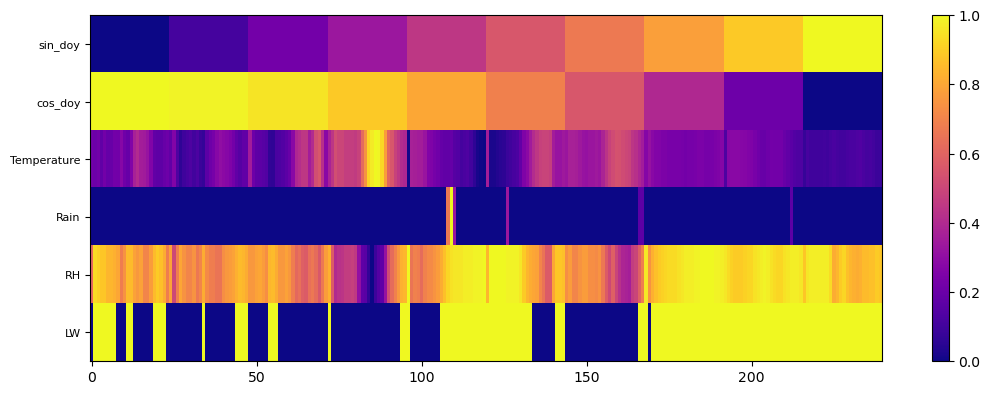

<Figure size 640x480 with 0 Axes>

In [10]:
col_labels = variables+ ["cos_doy", "sin_doy"]
plot_time_series(X_train[0], col_labels[::-1])# flip labels becasue apparently heatmap goes from bottom to top

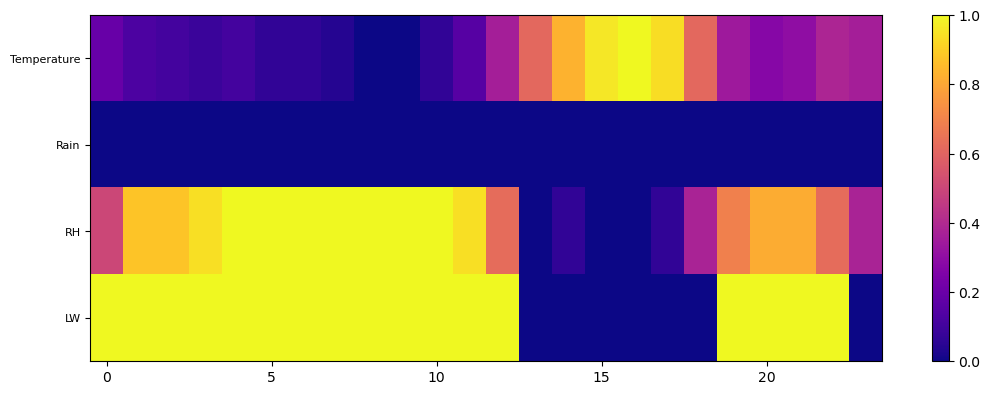

<Figure size 640x480 with 0 Axes>

In [11]:
plot_time_series(Y_train[0], variables[::-1])# flip labels becasue apparently heatmap goes from bottom to top

# Creating the Support set
Now we have a training and a test set for the meta-task model, what we are still missing is the support set, i.e. the training data for the *actual task* we wanted to learn in first place.

In [12]:
def build_support_data_points(df, window_size, interesting_columns, point_timestamps):
    for ts in point_timestamps:
        start = pd.to_datetime(ts)+ timedelta(hours=randrange(5,12))
        end = start - timedelta(hours=window_size-1)
        slice_df = df.loc[end:start].copy()[interesting_columns]
        if len(slice_df) == window_size:
            yield slice_df.to_numpy()

We are going to re-use much of the logic we used for the meta-training set becasue the resulting data must have the same shape, the real difference here is the Y tesor that, instead of sequences, it will include more discrete values, namely [1,0] for positive samples and [0,1] for negative ones.

Why this convention? Becasue you can easily generalize that to a multi-classification scenario (i.e. with more labels than just positive and negative) simply by adding more positions to the Y vector with minimal impacts on the reminder of the code hereby presented.

In [13]:
def build_support_set(df_w, df_pat, target_column,  interesting_columns = ['LW','RH','Rain','Temperature'], resample_freq = resample_freq, seq_len = seq_len):
    # pathogen presence or lack of thereof
    positives = pd.to_datetime(df_pat.loc[df_pat[target_column] > 0]['RowKey'])
    negatives = pd.to_datetime(df_pat.loc[df_pat[target_column] == 0].sample(n = len(positives))['RowKey'])
    # weather data preparation
    df_w = resample_dataframe(df_w, interesting_columns = interesting_columns, 
                            resample_freq =resample_freq , timestamp_column = 'RowKey')
    # feature engineering time
    df_w, extra_features = eng_weather_data(df_w)
    # output data structures
    x = []
    y = []
    for time_series in build_support_data_points(df_w, window_size = seq_len, interesting_columns = interesting_columns + extra_features, point_timestamps=positives):
        x.append(time_series)
        y.append([1, 0])
    for time_series in build_support_data_points(df_w, window_size = seq_len, interesting_columns = interesting_columns + extra_features, point_timestamps=negatives):
        x.append(time_series)
        y.append([0, 1])
    return x, y

In [14]:
x_support, y_support = build_support_set(weather, observations, target_column= 'Botrite', 
                                         interesting_columns = variables, resample_freq = resample_freq,
                                         seq_len = seq_len)

	 resampling data


Let's plot a data series from how support set to see if it looks like the ones from the training set.

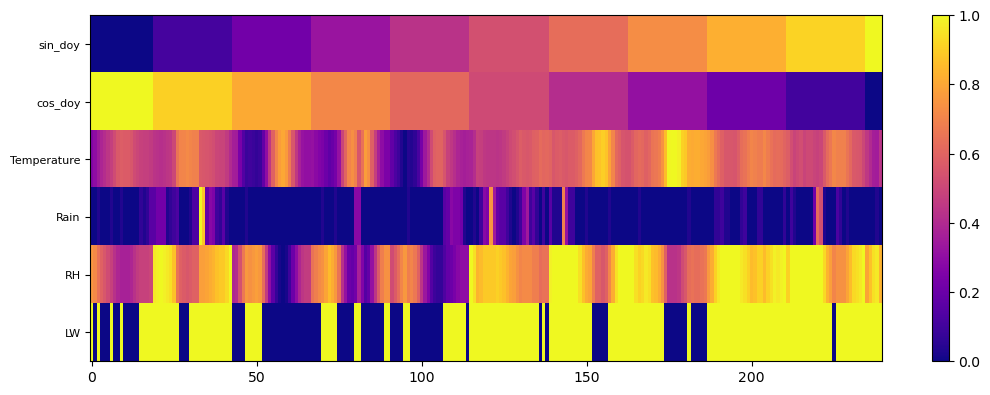

<Figure size 640x480 with 0 Axes>

In [15]:
plot_time_series(x_support[0], col_labels[::-1])

It definitely does!

Now we can save our support set for later use. We also need to shuffle the training part of the support set becasue Keras will always pick the last elements as validation and we'd like our validation part to be randomized.

In [16]:
def shuffle_data_set(x, y, iterations):
    '''Takes the vectorized representation of a data set and shuffles its components to indroduce a hefty amount of randomness'''
    assert len(x) == len(y), "Oh no! predictors and response length do not match!"
    last_index = len(x) - 1
    for i in range(iterations):
        a_index = round(random.random() * last_index)
        b_index = round(random.random() * last_index)
        x_value_a = x[a_index]
        y_value_a = y[a_index]
        x[a_index] = x[b_index]
        y[a_index] = y [b_index]
        x[b_index] = x_value_a
        y[b_index] = y_value_a
    return x, y

In [17]:
x_support, y_support = shuffle_data_set(x_support, y_support, len(x_support)*2)

In [18]:
x_support = np.array(x_support) 
y_support = np.array(y_support)

This ends the data preparation part, now we can move on to...
# The Meta-Learning part
The real fun starts here: we want to leverage the mass of data we collected to learn rather than a specific task, the general properties of our data, and then use this knowledge (encoded in a big pile of linear algebra) to rapidly learn specific tasks that don't have lots of data.
We'll do that with the following steps:
+ defining a "backbone", i.e. the transferrable part of the model
+ defining a metamodel that does a rather pointless task
+ train the metamodel for a looooooong time
+ detach the backbone
+ shove the backbone in a different model that is meant to learn a meaningful task (the support task)
+ train the 
The meta model will have inside a *backbone*, i.e. the part we will re-use for the actual task.

**Warning**: from now on things are getting *computationally heavy*, and you'd better get some GPU support.

The first thing to do is to check the GPU availability and to set it inmemory sharing mode, so we can run multiple models.

In [19]:
import tensorflow as tf
physical_devices = tf.config.experimental.list_physical_devices('GPU')
if len(physical_devices) > 0:
    print("We got a GPU")
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
else:
    print("Sorry, no GPU for you...")

2026-06-12 12:52:49.444990: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-12 12:52:49.591221: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX_VNNI, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Sorry, no GPU for you...


In [ ]:
import keras
from keras import layers, Model

In [21]:
dims = X_train.shape[-1]
y_dims = Y_train.shape[-1]
# how many time-points does the Y tensor have?
output_steps = int(Y_train.shape[1])

## Training the meta-model
In this cell we are defining the *backbone* i.e. the part of the network we'll re-use.
It's nothing fancy, just a couple of LSTM layers, but it should be enough to get most dynamics.

In [22]:
def build_lstm_backbone(seq_len, dims):
    input_l = layers.Input(
        shape=(seq_len, dims),
    )
    lstm_1 = layers.LSTM(64, return_sequences=True, implementation=1, activation = 'tanh')(input_l)
    lstm_2 = layers.LSTM(64, implementation=1, activation = 'tanh')(lstm_1)
    backbone_out = layers.Dense(64, activation="relu")(lstm_2)
    return Model(input_l, backbone_out, name='LSTM_backbone')

In [23]:
backbone = build_lstm_backbone(seq_len, dims)
backbone.summary()

Model: "LSTM_backbone"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 240, 6)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 240, 64)        │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,360 (216.25 KB)

 Trainable params: 55,360 (216.25 KB)

 Non-trainable params: 0 (0.00 B)

Our model has 55K parameters that, by deep learning standards, are few, but we won't need a mammoth-sized model to learn to fit our data, since we don't really have much of that either. Consider adding a few more layers if you are going to deal with bigger data sets with more complex dynamics to represent.

Now we put the backbone in a makeshift model for sequence prediction based on the [Seq2Seq](https://www.analyticsvidhya.com/blog/2020/08/a-simple-introduction-to-sequence-to-sequence-models/) architecture, basically we try to learn to predict the next few items in the sequence.

In [24]:
model_input = layers.Input(
        shape=(seq_len, dims),
    )

backbone_layer = backbone(model_input)
repeat_layer = layers.RepeatVector(output_steps)(backbone_layer)
# Decoder (second LSTM) 
decoder_layer = layers.LSTM(units=60, activation = 'tanh', return_sequences=True)(repeat_layer) 
# TimeDistributed is to ensure consistency between Dense and Decoder
out = layers.TimeDistributed(layers.Dense(y_dims, activation="linear"))(decoder_layer)


model = Model(model_input, out, name='meta-training')
model.summary()

Model: "meta-training"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 240, 6)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_backbone (Functional)      │ (None, 64)             │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 24, 60)         │        30,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 24, 4)          │           244 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,604 (334.39 KB)

 Trainable params: 85,604 (334.39 KB)

 Non-trainable params: 0 (0.00 B)

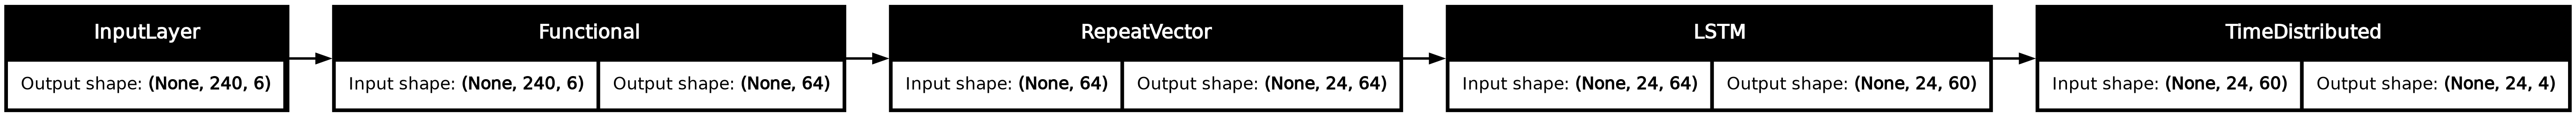

In [25]:
model.compile(optimizer="adam", loss="mean_squared_error")
keras.utils.plot_model(model, show_shapes=True, rankdir="LR")

In [ ]:
# batch_size=16,
# epochs=12,

history = model.fit(
            X_train,
            Y_train,
            batch_size=2,
            epochs=2,
            callbacks=[],
            validation_split = 0.1,
            verbose=1,
        )

Epoch 1/2
12503/12503 ━━━━━━━━━━━━━━━━━━━━ 3522s 281ms/step - loss: 27.2933 - val_loss: 3.6168
Epoch 2/2
 8854/12503 ━━━━━━━━━━━━━━━━━━━━ 16:30 271ms/step - loss: 24.4266

The epochs we use in this example are realy a few, and you can tell by the loss values that remain rather high. Finding the correct number of epochs for the model to run is an art, but for models like this one 100-ish is usually a good starting point.

What did our model learn? To predict how weather may evolve over the next day. Is it a reliable forecast? Nope, becasue weather is very, very hard to predict, especially rainfall, *however* the model knows what it reasonable to expect after a certain sequence/pattern of events, which is interesting.

Let's consider *temperature*, for instance:

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


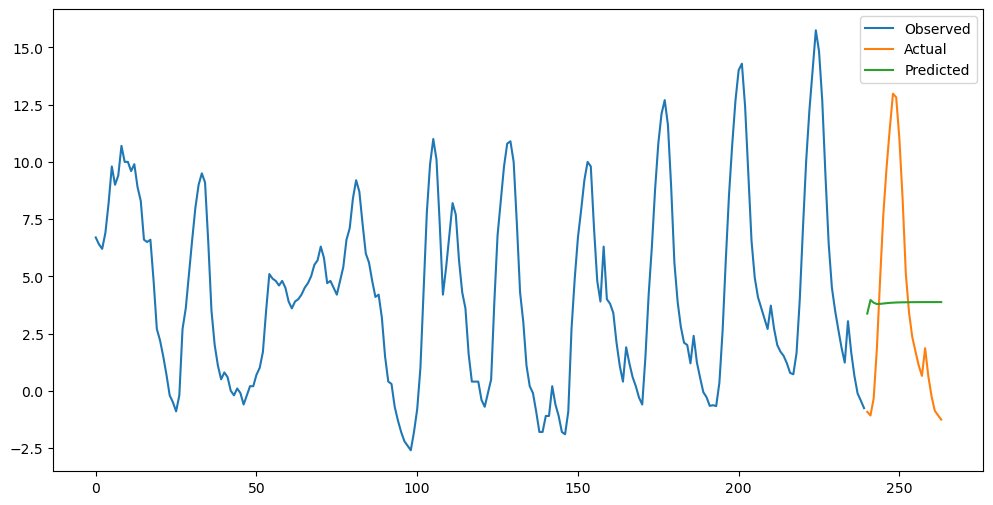

In [27]:
test_idx = -16
pred_x = model.predict(np.array([X_train[test_idx]]))

temp_x = np.transpose(X_train[test_idx])[3]
gt_temp = np.transpose(Y_train[test_idx])[3]
pred_temp = np.transpose(pred_x[0])[3]

plt.figure(figsize=(12, 6))
plt.plot( range(len(temp_x)), temp_x, label='Observed')
plt.plot( range(len(temp_x), len(temp_x)+len(gt_temp)),gt_temp, label='Actual')
plt.plot( range(len(temp_x), len(temp_x)+len(pred_temp)),pred_temp, label='Predicted')
plt.legend()
plt.show()

It's a godawful forecast (afeter all the model is underfitting due to the small numbers of training epochs), but if we average these values we are not that far from the actual average temperature, that means the model now knows what average temperature is to be expected, that means the model has some undestanding of what the weather data means.

Let's pretend we are happy with our model and save it.

In [28]:
backbone.save('metamodel.keras')

# Flossing the support set
Now that we have the meta-model, we can start tackling the *real* problem.
Let's load the trained model, just to demonstrate the save/load functionality.

In [29]:
backbone = keras.models.load_model('metamodel.keras')

Now we can use the meta-model to build for each sequence in our support set a vectorial representation.
These vectors are as large as the metamodel output layer, in our case they have 64 positions, such vectors embed the "meaning" of a sequence, i.e. the information about what to expect next.
## Vector Space Exploration
To get a hold on what the space the meta-model learnt looks like, we can perform a Principal Component Analysis and then plot the positive and negative points in two dimensions.

In [30]:
from sklearn.decomposition import PCA

train_labels = [c[0] for c in y_support]
x_representation = backbone.predict(x_support)

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_representation)

print(pca.explained_variance_ratio_)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 301ms/step
[0.8255075 0.1583522]


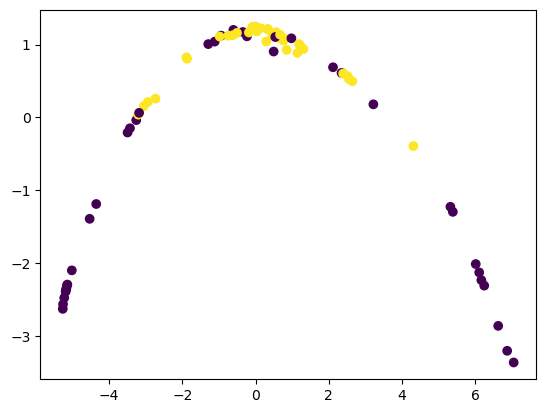

In [31]:
plt.scatter(*zip(*x_pca), c=train_labels)

Interestingly enough, the positive points occupy a rather compact region of our space, implying the meta-model learnt to cluster the conditions that lead to Botritis even though it wasn't trained for this.

But is it really the case? And are these points separable from the negative ones? We can try to sort that out with Linear Discriminant Analysis. Will such an analysis manage to separate positive from negative points?

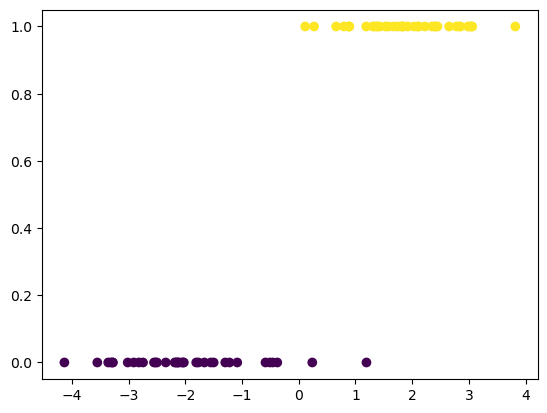

In [32]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
x_lda = lda.fit(x_representation, train_labels).transform(x_representation)

plt.scatter(x_lda, train_labels, c=train_labels)

Well, not completely, but close enough! Time to move on to the actual learning part.
## Training a support model
Up to know we didn't alter the meta-model, but we can tune it to better fit the actual problem.
We can use our meta-model as backbone of a classification model, and train it on our support task. The idea is to use the meta-training as a starting point for a new training and the assumption is the weights learnt during the meta-training represent a much better (and safer) starting point for the gradient descent with respect to the support task.

In [33]:
from sklearn.model_selection import train_test_split

support_task_y_dims = y_support.shape[-1]

x_support_train, x_support_test, y_support_train, y_support_test = train_test_split(x_support, y_support, test_size=0.1, random_state=42)

In [34]:
task_model_input = layers.Input(
        shape=(seq_len, dims),
    )

task_backbone_layer = backbone(task_model_input)

task_hidden = layers.Dense(128, activation="relu")(task_backbone_layer)
task_second_hidden = layers.Dense(64, activation="relu")(task_hidden)
task_drop_layer = layers.Dropout(0.25)(task_second_hidden)
task_out = layers.Dense(support_task_y_dims, activation="softmax")(task_drop_layer)

task_model = Model(task_model_input, task_out, name='actual_task_model')
task_model.summary()

Model: "actual_task_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 240, 6)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_backbone (Functional)      │ (None, 64)             │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,066 (281.51 KB)

 Trainable params: 72,066 (281.51 KB)

 Non-trainable params: 0 (0.00 B)

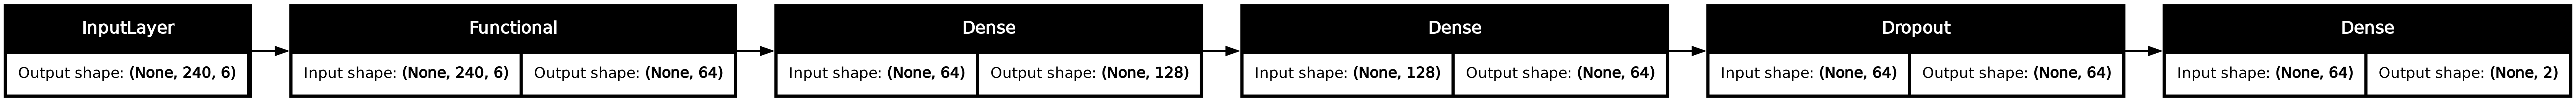

In [35]:
task_model.compile(optimizer="adam", loss="categorical_crossentropy")
keras.utils.plot_model(task_model, show_shapes=True, rankdir="LR")

In [ ]:
# batch_size=8,
# epochs=6,

history = task_model.fit(
            x_support_train,
            y_support_train,
            batch_size=2,
            epochs=2,
            callbacks=[],
            validation_split = 0.1,
            verbose=1,
        )

Epoch 1/6
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 549ms/step - loss: 0.7008 - val_loss: 0.5284
Epoch 2/6
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 546ms/step - loss: 0.6172 - val_loss: 0.3541
Epoch 3/6
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 489ms/step - loss: 0.5612 - val_loss: 0.2612
Epoch 4/6
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 488ms/step - loss: 0.5115 - val_loss: 0.2652
Epoch 5/6
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 516ms/step - loss: 0.4761 - val_loss: 0.2363
Epoch 6/6
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 500ms/step - loss: 0.4829 - val_loss: 0.2060


Let's now see how it performs on the test split, i.e. data it has never ever seen before.

In [37]:
preds = task_model.predict(x_support_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 551ms/step


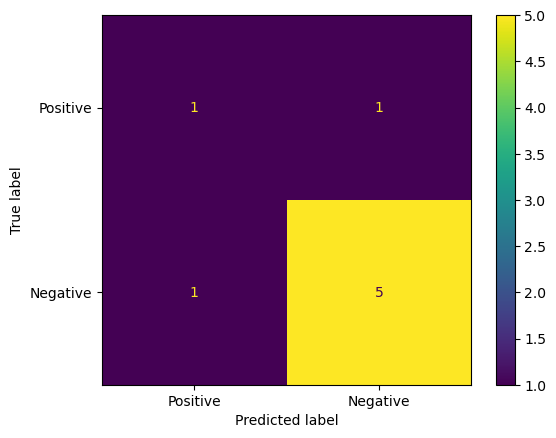

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(np.transpose(y_support_test)[0], np.transpose(np.round(preds))[0])
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Positive', 'Negative']).plot()

Considering the ridicolously small size our dataset, that's not bad at all!